In [1]:
from aoespy import *
import xarray as xr
dir='/nobackupp27/afahad/exp/'
data='/nobackupp27/afahad/exp/script_replay_AGU/data/'

/home6/afahad/.local/lib/python3.9/site-packages/aoespy.py:19: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
#cntrl=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT44_cntrl/holding/geosgcm_surf/200505/*surf*200505*z.nc4').sel(time=slice('2005-04','2006-04'))
cntrl=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_ME0416/holding/geosgcm_surf/200504/*surf*200504*z.nc4').sel(time=slice('2005-04','2006-04'))
rep=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_RP0416/holding/geosgcm_surf/200504/*surf*200504*z.nc4').sel(time=slice('2005-04','2006-04'))
#rep=rep.sel(time=slice('2005-05','2006-04'))

In [9]:
import datetime
from datetime import date
import numpy as np
print(date.toordinal(date(1970,1,1)))
deltaT=3600

719163


In [4]:
def ordinal_to_string(ordinal):
    date = datetime.date.fromordinal(ordinal)
    return date.strftime("%B %-d, %Y")

In [10]:
ts=np.array([116388, 116508, 116628, 116748, 116868, 116988])

In [25]:
date.toordinal(date(1992,1,1.5))#+(116508*deltaT)/86400

TypeError: integer argument expected, got float

In [23]:
ordinal_to_string(732052)

'April 16, 2005'

In [3]:
cntrlP=(cntrl.PRECTOT.compute())*86400
repP=(rep.PRECTOT.compute())*86400

In [4]:
cntrlPs=(cntrl.PS.compute())
repPs=(rep.PS.compute())

In [5]:
cntrlT=(cntrl.TS.compute())
repT=(rep.TS.compute())

In [6]:
cntrlL=(cntrl.LHFX.compute())
repL=(rep.LHFX.compute())

In [7]:
cntrl6=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT44_cntrl/holding/geosgcm_surf/200506/*surf*200506*z.nc4').sel(time=slice('2005-04','2006-04'))
rep6=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT41_ciauF/holding/geosgcm_surf/200506/*surf*z.nc4').sel(time=slice('2005-04','2006-04'))

In [8]:
cntrlP6=(cntrl6.PRECTOT.compute())*86400
repP6=(rep6.PRECTOT.compute())*86400

In [9]:
cntrlPs6=(cntrl6.PS.compute())
repPs6=(rep6.PS.compute())

In [10]:
cntrlL6=(cntrl6.LHFX.compute())
repL6=(rep6.LHFX.compute())

In [11]:
cntrlT6=(cntrl6.TS.compute())
repT6=(rep6.TS.compute())

In [12]:
repP=xr.concat([repP,repP6],dim='time')
cntrlP=xr.concat([cntrlP,cntrlP6],dim='time')

In [13]:
repPs=xr.concat([repPs,repPs6],dim='time')
cntrlPs=xr.concat([cntrlPs,cntrlPs6],dim='time')

In [14]:


repT=xr.concat([repT,repT6],dim='time')
cntrlT=xr.concat([cntrlT,cntrlT6],dim='time')

In [15]:
repL=xr.concat([repL,repL6],dim='time')
cntrlL=xr.concat([cntrlL,cntrlL6],dim='time')

In [11]:
free=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT43_free/holding/geosgcm_surf/200505/*surf*200505*z.nc4').sel(time=slice('2005-04','2006-04'))
free6=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT43_free/holding/geosgcm_surf/200506/*surf*200506*z.nc4').sel(time=slice('2005-04','2006-04'))

In [12]:
fP=(free.PRECTOT.compute())*86400
fP6=(free6.PRECTOT.compute())*86400
fP=xr.concat([fP,fP6],dim='time')

fT=(free.TS.compute())
fT6=(free6.TS.compute())
fT=xr.concat([fT,fT6],dim='time')

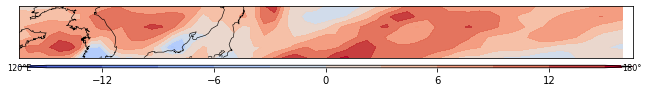

In [31]:
repPsT=(repPs[1:,:,:]-repPs[:-1,:,:].data)/delta_t
cntrlPsT=(cntrlPs[1:,:,:]-cntrlPs[:-1,:,:].data)/delta_t

(0.0, 80.0)

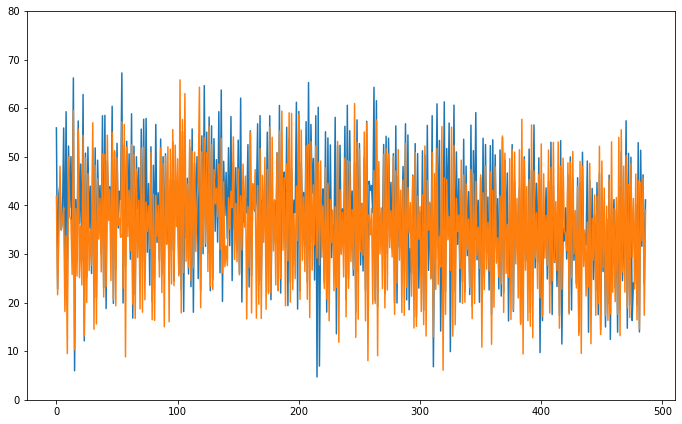

In [57]:
y1=10;y2=12;x1=-112;x2=-110;

f()
plt.plot(abs(repPsT.sel(lat=slice(y1,y2),lon=(x1,x2))).mean(dim=['lat','lon']))

plt.plot(abs(cntrlPsT.sel(lat=slice(y1,y2),lon=(x1,x2))).mean(dim=['lat','lon']))
plt.ylim(0,80)

In [12]:
delta_t = 3

# Calculate the tendency (rate of change)
repPst = np.diff(repPs, axis=0) / delta_t
repPsT = np.zeros_like(repPs)
repPsT[1:, :, :] = repPst  # Leave the first timestep as 0 or NaN
repPsT[0, :, :] = np.nan  # Optional: NaN for the first timestep

In [13]:
cntrlPst = np.diff(cntrlPs, axis=0) / delta_t
cntrlPsT = np.zeros_like(cntrlPs)
cntrlPsT[1:, :, :] = cntrlPst  # Leave the first timestep as 0 or NaN
cntrlPsT[0, :, :] = np.nan  # Optional: NaN for the first timestep

In [5]:
# repstd=nanstd(repPs.sel(time=slice('2005-05-01','2005-06-30')),0)
# cntstd=nanstd(cntrlPs.sel(time=slice('2005-05-01','2005-06-30')),0)
repstd=nanstd((repP.sel(time='2005-04')),0)
cntstd=nanstd((cntrlP.sel(time='2005-04')),0)

(array([[-180., -179., -178., ...,  177.,  178.,  179.],
        [-180., -179., -178., ...,  177.,  178.,  179.],
        [-180., -179., -178., ...,  177.,  178.,  179.],
        ...,
        [-180., -179., -178., ...,  177.,  178.,  179.],
        [-180., -179., -178., ...,  177.,  178.,  179.],
        [-180., -179., -178., ...,  177.,  178.,  179.]]),
 array([[-90., -90., -90., ..., -90., -90., -90.],
        [-89., -89., -89., ..., -89., -89., -89.],
        [-88., -88., -88., ..., -88., -88., -88.],
        ...,
        [ 88.,  88.,  88., ...,  88.,  88.,  88.],
        [ 89.,  89.,  89., ...,  89.,  89.,  89.],
        [ 90.,  90.,  90., ...,  90.,  90.,  90.]]),
 <mpl_toolkits.basemap.Basemap at 0x1477edb35700>)

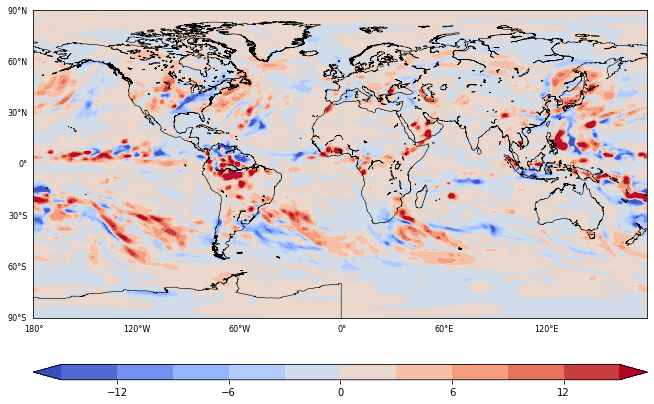

In [18]:
plt.figure(figsize=(11,8.5))

clf=arange(-15,16,3)

x1=120
x2=180
y1=35
y2=40
plot(cntstd-repstd,cntrl.lon,cntrl.lat,clf=clf)#,lon1=x1,lon2=x2,lat1=y1,lat2=y2);

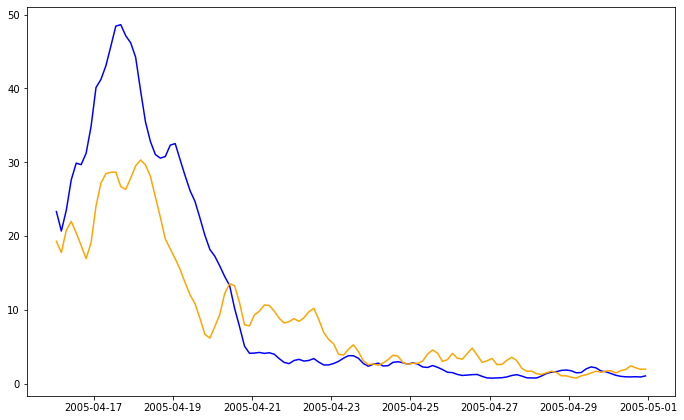

In [26]:
x1=160
x2=180
y1=-20
y2=-15


lon=(cntrlP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lon
lat=(cntrlP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lat

f()
plt.plot(cntrlP.time,(cntrlP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
plt.plot(cntrlP.time,(repP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

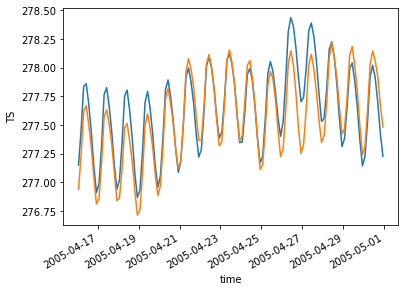

In [36]:
cntrl.TS.mean(dim=['lat','lon']).plot()
rep.TS.mean(dim=['lat','lon']).plot()

Text(0.5, 1.0, 'STD of MAY2005 3hrly, MERRA2-ECCO IC minus IAU IC')

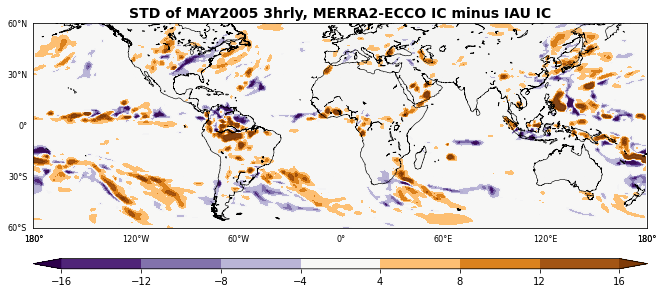

In [9]:
plt.figure(figsize=(11,8.5))
clf=array([-4,-3,-2,-1,1,2,3,4])*4

map=plot((cntstd)-(repstd),cntrl.lon,cntrl.lat,clf=clf, lat1=-60, lat2=60, cmap='PuOr_r');
map[2].drawlsmask()
plt.title("STD of MAY2005 3hrly, MERRA2-ECCO IC minus IAU IC", fontsize=14, fontweight='bold')
#plt.savefig('STD_TS.png',dpi=250)

Text(0.5, 1.0, 'STD of MAY2005 3hrly, MERRA2-ECCO IC minus IAU IC')

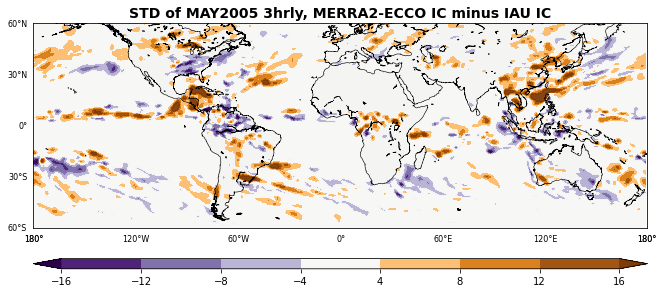

In [9]:
plt.figure(figsize=(11,8.5))
clf=array([-4,-3,-2,-1,1,2,3,4])*

map=plot((cntstd)-(repstd),cntrl.lon,cntrl.lat,clf=clf, lat1=-60, lat2=60, cmap='PuOr_r');
map[2].drawlsmask()
plt.title("STD of MAY2005 3hrly, MERRA2-ECCO IC minus IAU IC", fontsize=14, fontweight='bold')
#plt.savefig('STD_TS.png',dpi=250)

Text(0.5, 1.0, 'STD of MAY2005 3hrly TS, MERRA2-ECCO IC minus IAU IC')

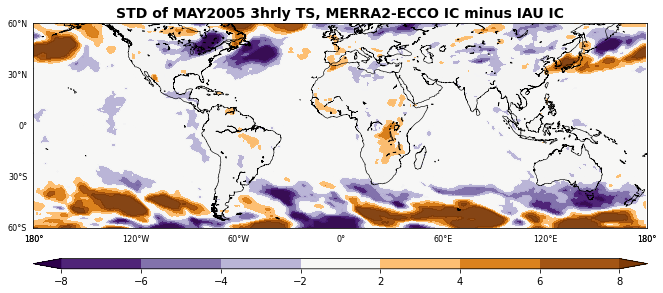

In [21]:
plt.figure(figsize=(11,8.5))
clf=array([-4,-3,-2,-1,1,2,3,4])*2

map=plot((cntstd)-(repstd),cntrl.lon,cntrl.lat,clf=clf, lat1=-60, lat2=60, cmap='PuOr_r');
map[2].drawlsmask()
plt.title("STD of MAY2005 3hrly TS, MERRA2-ECCO IC minus IAU IC", fontsize=14, fontweight='bold')
#plt.savefig('STD_TS.png',dpi=250)

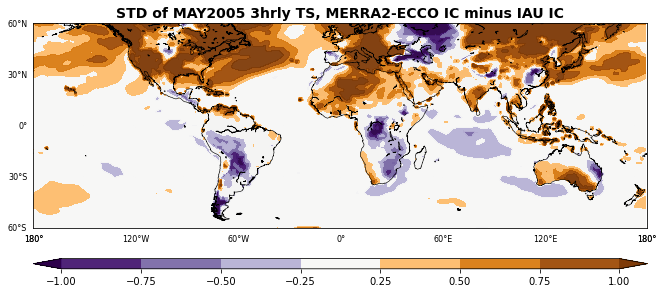

In [155]:
plt.figure(figsize=(11,8.5))
clf=array([-4,-3,-2,-1,1,2,3,4])*.25

map=plot(cntstd-repstd,cntrl.lon,cntrl.lat,clf=clf, lat1=-60, lat2=60, cmap='PuOr_r');
map[2].drawlsmask()
plt.title("STD of MAY2005 3hrly TS, MERRA2-ECCO IC minus IAU IC", fontsize=14, fontweight='bold')
plt.savefig('STD_TS.png',dpi=250)

In [152]:
# plt.figure(figsize=(11,8.5))

# clf=arange(-45,46,10)
# map=plot(cntstd-repstd,cntrl.lon,cntrl.lat,clf=clf, lat1=-60, lat2=60, cmap='PuOr_r');
# map[2].drawlsmask()
# plt.title("STD of MAY2005 3hrly TS, MERRA2-ECCO IC minus IAU IC", fontsize=14, fontweight='bold')
# plt.savefig('STD_LH.png',dpi=250)

Text(0.5, 1.0, 'STD of MAY2005 3hrly precip, MERRA2-ECCO IC minus IAU IC')

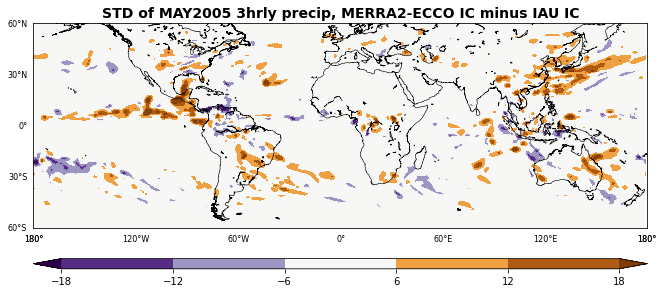

In [22]:
plt.figure(figsize=(11,8.5))

clf=arange(-18,19,4)
clf=np.array([-18,-12,-6,6,12,18])
plot(cntstd-repstd,cntrl.lon,cntrl.lat,clf=clf, lat1=-60, lat2=60, cmap='PuOr_r');

plt.title("STD of MAY2005 3hrly precip, MERRA2-ECCO IC minus IAU IC", fontsize=14, fontweight='bold')
#plt.savefig('STD.png',dpi=250)

In [16]:
ticks=[]

for i in range(len(cntrlP.time)):
    ticks=append(ticks,str(cntrlP.time.data[i])[8:16])

In [129]:
# plt.figure(figsize=(12,8.5))
# plt.subplot(2,2,1)

# x1=120
# x2=130
# y1=40
# y2=50


# lon=(cntrlP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lon
# lat=(cntrlP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lat

# plt.plot((cntrlP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((repP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='red')
# plt.plot(fP.sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='black',alpha=.5)
# plt.legend(['MERRA2-ECCO IC', 'IAU IC', 'Free Running Exp'])
 
# plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
# plt.title('Precip Western North Pacific [120:130E; 40-50N]',fontweight='bold')
# plt.xlabel('May 2005                                     June 2005')
# plt.ylabel(r'mm $day{-1}$')

# plt.subplot(2,2,2)
# x1=150
# x2=160
# y1=-20
# y2=-15

# lon=(cntrlP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lon
# lat=(cntrlP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lat

# plt.plot((cntrlP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((repP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='red')
# plt.plot(fP.sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='black',alpha=.5)
# plt.legend(['MERRA2-ECCO IC', 'IAU IC', 'Free Running Exp'])
 
# plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
# plt.title('Precip SPCZ [150:160E; 15-20S]',fontweight='bold')
# plt.xlabel('May 2005                                     June 2005')
# plt.ylabel(r'mm $day{-1}$')


# plt.subplot(2,2,3)
# x1=85
# x2=92
# y1=-10
# y2=10

# lon=(cntrlP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lon
# lat=(cntrlP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lat

# plt.plot((cntrlP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((repP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='red')
# plt.plot(fP.sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='black',alpha=.5)
# plt.legend(['MERRA2-ECCO IC', 'IAU IC', 'Free Running Exp'])
 
# plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
# plt.title('Precip Indian Ocean [85:95E; 10S-10N]',fontweight='bold')
# plt.xlabel('May 2005                                     June 2005')
# plt.ylabel(r'mm $day{-1}$')


# plt.subplot(2,2,4)


# x1=-50
# x2=-30
# y1=20
# y2=30


# lon=(cntrlP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lon
# lat=(cntrlP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lat

# plt.plot((cntrlP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((repP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='red')
# plt.plot(fP.sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='black',alpha=.5)
# plt.legend(['MERRA2-ECCO IC', 'IAU IC', 'Free Running Exp'])
 
# plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
# plt.title('Precip North Atlantic Ocean [30:50W; 20-30N]',fontweight='bold')
# plt.xlabel('May 2005                                     June 2005')
# plt.ylabel(r'mm $day{-1}$')

# plt.tight_layout()
# plt.savefig('Pr_variability.png',dpi=250)

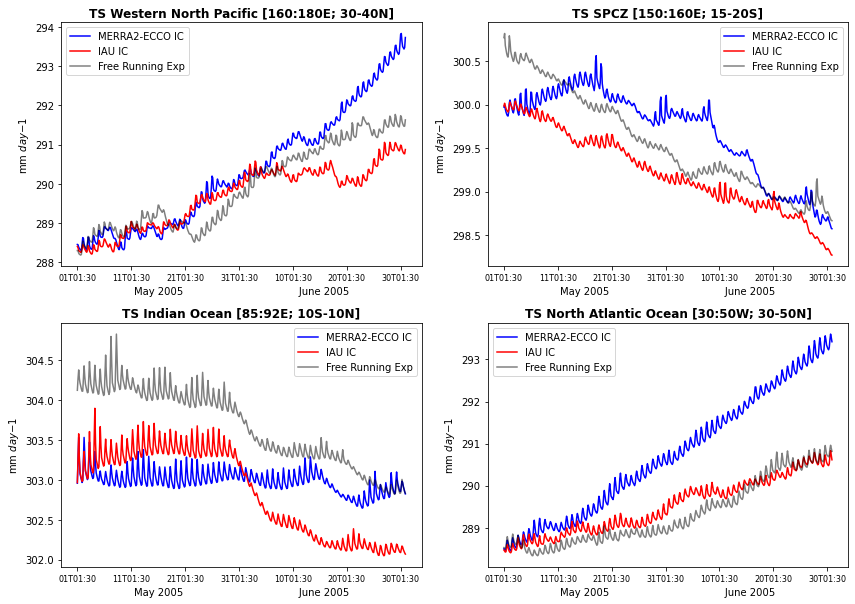

In [137]:
plt.figure(figsize=(12,8.5))
plt.subplot(2,2,1)

x1=160
x2=180
y1=30
y2=40


lon=(cntrlT).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lon
lat=(cntrlT).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lat

plt.plot((cntrlT).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
plt.plot((repT).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='red')
plt.plot(fT.sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='black',alpha=.5)
plt.legend(['MERRA2-ECCO IC', 'IAU IC', 'Free Running Exp'])
 
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.title('TS Western North Pacific [160:180E; 30-40N]',fontweight='bold')
plt.xlabel('May 2005                                     June 2005')
plt.ylabel(r'mm $day{-1}$')

plt.subplot(2,2,2)
x1=150
x2=160
y1=-20
y2=-15

lon=(cntrlT).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lon
lat=(cntrlT).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lat

plt.plot((cntrlT).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
plt.plot((repT).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='red')
plt.plot(fT.sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='black',alpha=.5)
plt.legend(['MERRA2-ECCO IC', 'IAU IC', 'Free Running Exp'])
 
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.title('TS SPCZ [150:160E; 15-20S]',fontweight='bold')
plt.xlabel('May 2005                                     June 2005')
plt.ylabel(r'mm $day{-1}$')


plt.subplot(2,2,3)
x1=85
x2=92
y1=-10
y2=10

lon=(cntrlT).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lon
lat=(cntrlT).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lat

plt.plot((cntrlT).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
plt.plot((repT).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='red')
plt.plot(fT.sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='black',alpha=.5)
plt.legend(['MERRA2-ECCO IC', 'IAU IC', 'Free Running Exp'])
 
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.title('TS Indian Ocean [85:92E; 10S-10N]',fontweight='bold')
plt.xlabel('May 2005                                     June 2005')
plt.ylabel(r'mm $day{-1}$')


plt.subplot(2,2,4)


x1=-50
x2=-30
y1=30
y2=50


lon=(cntrlT).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lon
lat=(cntrlT).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lat

plt.plot((cntrlT).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
plt.plot((repT).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='red')
plt.plot(fT.sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='black',alpha=.5)
plt.legend(['MERRA2-ECCO IC', 'IAU IC', 'Free Running Exp'])
 
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.title('TS North Atlantic Ocean [30:50W; 30-50N]',fontweight='bold')
plt.xlabel('May 2005                                     June 2005')
plt.ylabel(r'mm $day{-1}$')

plt.tight_layout()
plt.savefig('TS_variability.png',dpi=250)

In [135]:
# x1=-180
# x2=180
# y1=-5
# y2=5

# scntrlp=(cntrlP).sel(lat=slice(y1,y2),lon=slice(x1,x2))
# srepp=(repP).sel(lat=slice(y1,y2),lon=slice(x1,x2))

# for i in range(len(scntrlp.lon)):
#     for j in range(len(scntrlp.lat)):
#         plt.plot(scntrlp[:,j,i],color='blue')
#         plt.plot(srepp[:,j,i],color='red')


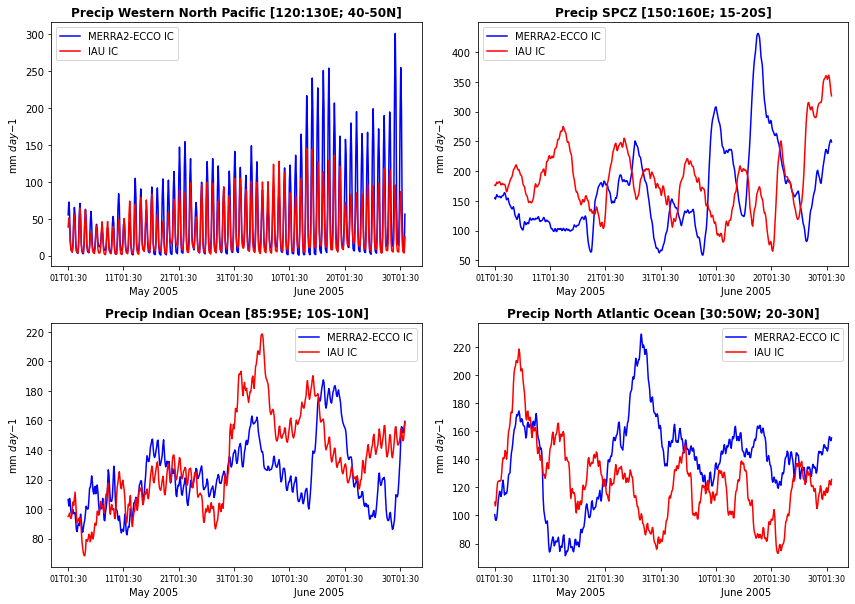

In [149]:
plt.figure(figsize=(12,8.5))
plt.subplot(2,2,1)

x1=120
x2=130
y1=40
y2=50


lon=(cntrlL).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lon
lat=(cntrlL).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lat

plt.plot((cntrlL).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
plt.plot((repL).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='red')
#plt.plot(fL.sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='black',alpha=.5)
plt.legend(['MERRA2-ECCO IC', 'IAU IC', 'Free Running Exp'])
 
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.title('Precip Western North Pacific [120:130E; 40-50N]',fontweight='bold')
plt.xlabel('May 2005                                     June 2005')
plt.ylabel(r'mm $day{-1}$')

plt.subplot(2,2,2)
x1=150
x2=160
y1=-20
y2=-15

lon=(cntrlL).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lon
lat=(cntrlL).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lat

plt.plot((cntrlL).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
plt.plot((repL).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='red')
#plt.plot(fL.sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='black',alpha=.5)
plt.legend(['MERRA2-ECCO IC', 'IAU IC', 'Free Running Exp'])
 
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.title('Precip SPCZ [150:160E; 15-20S]',fontweight='bold')
plt.xlabel('May 2005                                     June 2005')
plt.ylabel(r'mm $day{-1}$')


plt.subplot(2,2,3)
x1=85
x2=92
y1=-10
y2=10

lon=(cntrlL).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lon
lat=(cntrlL).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lat

plt.plot((cntrlL).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
plt.plot((repL).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='red')
#plt.plot(fL.sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='black',alpha=.5)
plt.legend(['MERRA2-ECCO IC', 'IAU IC', 'Free Running Exp'])
 
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.title('Precip Indian Ocean [85:95E; 10S-10N]',fontweight='bold')
plt.xlabel('May 2005                                     June 2005')
plt.ylabel(r'mm $day{-1}$')


plt.subplot(2,2,4)


x1=-50
x2=-30
y1=20
y2=30


lon=(cntrlL).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lon
lat=(cntrlL).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lat

plt.plot((cntrlL).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
plt.plot((repL).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='red')
#plt.plot(fL.sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='black',alpha=.5)
plt.legend(['MERRA2-ECCO IC', 'IAU IC', 'Free Running Exp'])
 
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.title('Precip North Atlantic Ocean [30:50W; 20-30N]',fontweight='bold')
plt.xlabel('May 2005                                     June 2005')
plt.ylabel(r'mm $day{-1}$')

plt.tight_layout()
plt.savefig('LH_variability.png',dpi=250)

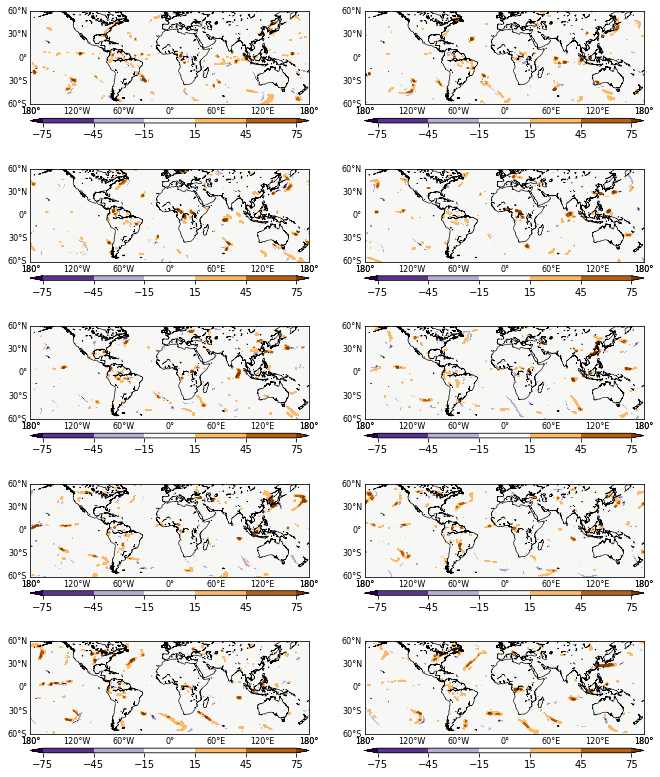

In [36]:
## Precip test

plt.figure(figsize=(11,14))

clf=arange(-100,101,20)

c=0;

for i in range(0,80,8):
    c=c+1
    
#     plt.subplot(3,1,1)
#     plot(cntrlP[i,:,:],cntrl.lon,cntrl.lat,clf=clf, lat1=-60, lat2=60, cmap='PuOr_r');

#     plt.subplot(3,1,2)
#     plot(repP[i,:,:],cntrl.lon,cntrl.lat,clf=clf, lat1=-60, lat2=60, cmap='PuOr_r');

    clf=arange(-75,76,30)
    plt.subplot(5,2,c)
    plot(cntrlP[i,:,:]-repP[i,:,:],cntrl.lon,cntrl.lat,clf=clf, lat1=-60, lat2=60, cmap='PuOr_r');



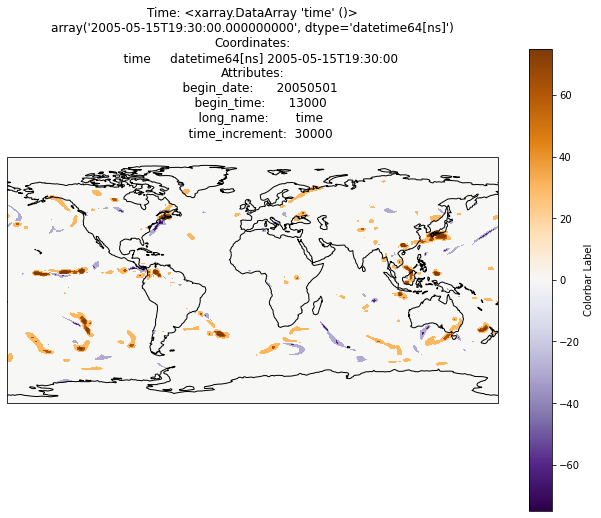

In [42]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from IPython.display import HTML, Image

# Set working directory if needed
os.chdir('/nobackupp27/afahad/scripts/initialization_shock/')

# Example level array
clf=arange(-75,76,30) # Preset levels for colorbar

# Create a figure with Cartopy projection
fig, ax = plt.subplots(figsize=(11,8.5),subplot_kw={'projection': ccrs.PlateCarree()})

# Add geographic features
ax.coastlines()
#ax.add_feature(cfeature.BORDERS, linestyle=':')
# ax.add_feature(cfeature.LAND, edgecolor='black')
# ax.add_feature(cfeature.LAKES, edgecolor='black')
# ax.add_feature(cfeature.RIVERS)

# Add colorbar
cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='PuOr_r', norm=plt.Normalize(vmin=clf.min(), vmax=clf.max())), ax=ax)
cbar.set_label('Colorbar Label')  # Customize label as needed

# Animation function
def animate2(i):
    ax.clear()  # Clear the axis to reset the plot for the next frame
    ax.coastlines()
    #ax.add_feature(cfeature.BORDERS, linestyle=':')
#     ax.add_feature(cfeature.LAND, edgecolor='black')
#     ax.add_feature(cfeature.LAKES, edgecolor='black')
#     ax.add_feature(cfeature.RIVERS)
    
    cs = ax.contourf(cntrl.lon, cntrl.lat, cntrlP[i,:,:]-repP[i,:,:], levels=clf, cmap='PuOr_r', extend='both', transform=ccrs.PlateCarree())
    ax.set_title(f"Time: {cntrl.time[i]}", loc='center', pad=20)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    return cs

ani = animation.FuncAnimation(fig, animate2, frames=range(0, 120, 2), interval=800, repeat=False)

# Generate and display the animation
HTML(ani.to_jshtml())

# Save the animation if needed
ani.save('animationPr.gif', writer='pillow', dpi=80)

# Display the saved animation
#Image(filename='animationw.gif')

#plt.show()


In [91]:
for j in range(180):
    for i in range(360):
        if nanmax(cntrlP[:,j,i]-repP[:,j,i])>120:
                  print(cntrl.lat[j].data,cntrl.lon[i].data,j,i)

-48.0 -154.0 42 26
-48.0 -153.0 42 27
-47.0 -155.0 43 25
-47.0 -154.0 43 26
-46.0 -156.0 44 24
-46.0 -155.0 44 25
-46.0 -75.0 44 105
-46.0 -47.0 44 133
-46.0 -10.0 44 170
-46.0 -9.0 44 171
-46.0 -8.0 44 172
-46.0 -7.0 44 173
-46.0 -6.0 44 174
-46.0 -5.0 44 175
-46.0 -4.0 44 176
-46.0 -3.0 44 177
-46.0 -2.0 44 178
-46.0 -1.0 44 179
-46.0 0.0 44 180
-46.0 73.0 44 253
-46.0 74.0 44 254
-45.0 -172.0 45 8
-45.0 -157.0 45 23
-45.0 -156.0 45 24
-45.0 -105.0 45 75
-45.0 -75.0 45 105
-45.0 -52.0 45 128
-45.0 -51.0 45 129
-45.0 -50.0 45 130
-45.0 76.0 45 256
-44.0 -170.0 46 10
-44.0 -159.0 46 21
-44.0 -158.0 46 22
-44.0 -157.0 46 23
-44.0 -143.0 46 37
-44.0 -142.0 46 38
-44.0 -141.0 46 39
-44.0 -140.0 46 40
-44.0 -108.0 46 72
-44.0 -107.0 46 73
-44.0 -73.0 46 107
-44.0 -54.0 46 126
-44.0 -40.0 46 140
-44.0 -38.0 46 142
-44.0 75.0 46 255
-44.0 77.0 46 257
-43.0 -144.0 47 36
-43.0 -143.0 47 37
-43.0 -142.0 47 38
-43.0 -141.0 47 39
-43.0 -140.0 47 40
-43.0 -139.0 47 41
-43.0 -138.0 47 42
-43.0 -137

10.0 111.0 100 291
10.0 116.0 100 296
10.0 117.0 100 297
10.0 122.0 100 302
10.0 123.0 100 303
10.0 124.0 100 304
10.0 131.0 100 311
10.0 132.0 100 312
10.0 141.0 100 321
10.0 142.0 100 322
10.0 144.0 100 324
10.0 145.0 100 325
11.0 -114.0 101 66
11.0 -113.0 101 67
11.0 -95.0 101 85
11.0 -94.0 101 86
11.0 -93.0 101 87
11.0 -92.0 101 88
11.0 -89.0 101 91
11.0 -88.0 101 92
11.0 -87.0 101 93
11.0 -86.0 101 94
11.0 -82.0 101 98
11.0 -77.0 101 103
11.0 -76.0 101 104
11.0 -75.0 101 105
11.0 116.0 101 296
11.0 117.0 101 297
11.0 119.0 101 299
11.0 120.0 101 300
11.0 121.0 101 301
11.0 122.0 101 302
11.0 123.0 101 303
11.0 127.0 101 307
11.0 128.0 101 308
11.0 131.0 101 311
12.0 -113.0 102 67
12.0 -104.0 102 76
12.0 -103.0 102 77
12.0 -96.0 102 84
12.0 -95.0 102 85
12.0 -94.0 102 86
12.0 -93.0 102 87
12.0 -92.0 102 88
12.0 -90.0 102 90
12.0 -88.0 102 92
12.0 -83.0 102 97
12.0 -82.0 102 98
12.0 120.0 102 300
13.0 -114.0 103 66
13.0 -113.0 103 67
13.0 -104.0 103 76
13.0 -103.0 103 77
13.0 -97.0 

62.0 -55.0 152 125
62.0 -54.0 152 126
62.0 -53.0 152 127
63.0 -56.0 153 124
63.0 -55.0 153 125
63.0 -54.0 153 126
63.0 -53.0 153 127
64.0 -55.0 154 125


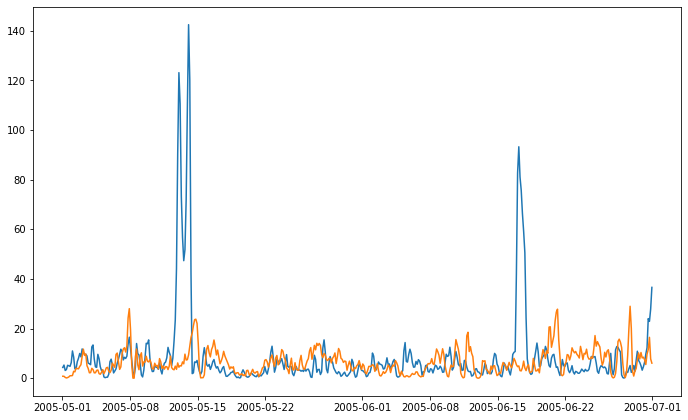

In [99]:
y1=0; y2=0
x1=129; x2=129

f()
plt.plot(cntrlP.time,cntrlP.sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']))
plt.plot(repP.time,repP.sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']))

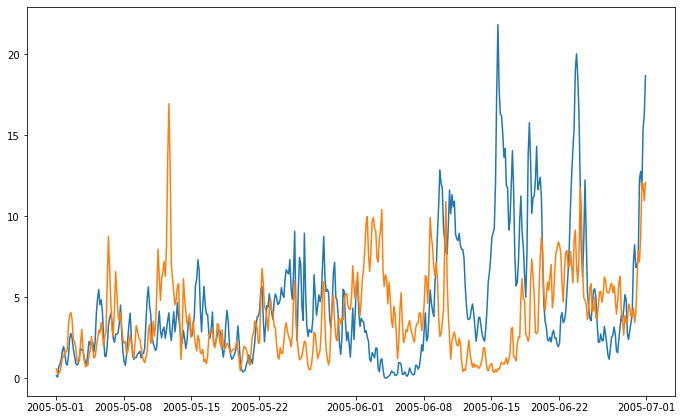

In [102]:
y1=13; y2=13
x1=129; x2=135

f()
plt.plot(cntrlP.time,cntrlP.sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']))
plt.plot(repP.time,repP.sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']))